# scoring dancehall tracks  

now, we'll load our best model (`hist-gbm` trained on all features) and use it to score the trinidad dancehall tracks and analyze the findings.

## setup

### loading artifacts

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# path constants
BASE_MODEL_ARTIFACTS_PATH = Path(".") / "model_artifacts" / "all_features"
BASE_DATA_PATH = Path(".") / "data"

# load model and artifacts
best_model = joblib.load(BASE_MODEL_ARTIFACTS_PATH  / "hist_gbm_model.joblib")
scaler = joblib.load(BASE_MODEL_ARTIFACTS_PATH / "fitted_scaler.joblib")
encoder = joblib.load(BASE_MODEL_ARTIFACTS_PATH / "fitted_encoder.joblib")

# load dataset
raw_dancehall_df = pd.read_csv(BASE_DATA_PATH / "trini_dancehall-track-attributes.csv", index_col='track_id')
raw_dancehall_df

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,time_signature,track_name,track_artists_id,track_artists_name,track_artists_followers,track_artists_popularity,release_date,release_date_precision,popularity,generated_timestamp
track_id,,,,,,,,,,,,,,,,,,,,,
2Y3EY4bEFhRbRvys4Fo9jK,0.594,0.469,4,-9.192,0,0.476,0.412,0.000003,0.0911,0.473,...,5,World War 3,3r8Hq14XJAyy6K8mlBs2s5,Rebel Sixx,50069,32,2020-02-13,day,30,2023-12-19
3YK38gmKuG9reDly3KeKQ8,0.817,0.441,8,-9.154,0,0.311,0.494,0.000012,0.0749,0.433,...,4,Weak Heart,3r8Hq14XJAyy6K8mlBs2s5,Rebel Sixx,50069,32,2020-01-17,day,23,2023-12-19
5wPcFRwPMK1aVhboTtJK5f,0.833,0.511,0,-7.910,0,0.202,0.730,0.000000,0.2240,0.490,...,4,Rifle War,3r8Hq14XJAyy6K8mlBs2s5,Rebel Sixx,50069,32,2020-01-01,day,37,2023-12-19
0MCA6RAlibvowsEaZy9p8y,0.688,0.734,6,-3.922,0,0.437,0.569,0.000000,0.3150,0.501,...,4,Welcome 2 TriniBad,"6QJrx4J9XqIxXUBhacoJHC,22VTLijlsfRm7CFJPHnj72","Medz Boss,Icee Dan","33706,13","26,0",2020-03-06,day,35,2023-12-19
3KowpMVfbYubAEk68w8qT1,0.738,0.629,9,-10.361,0,0.405,0.316,0.000005,0.0903,0.318,...,5,Work,"6QJrx4J9XqIxXUBhacoJHC,4Eg9wMIN73JI2iMSj1b05y","Medz Boss,Kyler","33706,67","26,4",2019-10-17,day,14,2023-12-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0fz2jINcCa4iD7j4dmioCa,0.731,0.813,2,-3.055,1,0.238,0.298,0.000000,0.1680,0.583,...,4,Dye Dye (Raw),6ETpDuVbzktDEfNza1CN8i,Macka Diamond,54833,33,2013-03-06,day,51,2023-12-19
5QFDEK8REzHTuCePAxOujd,0.562,0.765,5,-4.835,0,0.102,0.134,0.000000,0.0772,0.776,...,4,Associate,5sK8BsvyDl4TFA6KaBf8or,Charly Black,339566,58,2017-09-01,day,44,2023-12-19
5MXmLShFwWQTBSgnbTo2PL,0.753,0.654,6,-6.517,1,0.207,0.201,0.000000,0.1730,0.618,...,5,Nah Fi Like,2LIAgeQ5NZurwixfoG3CWZ,Alkaline,487214,54,2020-04-20,day,35,2023-12-19


### pre-processing

we'll need to load our fitted scaler + encoder as well as the feature transforms and use them to prepare our dataset for scoring 

In [2]:
from src.data_processing import (
    ALL_FEATURE_DTYPE_MAP,
    CATEGORICAL_COLS,
    TARGET_AUDIO_FEATURE_LIST,
    TARGET_RESPONSE,
    TRACK_METADATA_FEATURE_LIST,
)
from src.data_processing.feature_transforms import create_common_features

# full feature list
ALL_FEATURE_COLS = [
    *TARGET_AUDIO_FEATURE_LIST,
    *TRACK_METADATA_FEATURE_LIST,
    TARGET_RESPONSE
]

# apply common transforms
base_modelling_df = create_common_features(track_df=raw_dancehall_df, sep=",")

# subset to relevant cols and fix types
modelling_df = base_modelling_df[ALL_FEATURE_COLS].drop(columns=TARGET_RESPONSE)
modelling_df = modelling_df.astype(ALL_FEATURE_DTYPE_MAP)

# apply scaling + encoding (to just relevant cols and combine later)
encoded_modelling_data= encoder.transform(modelling_df[CATEGORICAL_COLS])
scaled_modelling_data= scaler.transform(modelling_df.drop(columns=CATEGORICAL_COLS, axis=1))

# convert back to dataframes
encoded_modelling_df = pd.DataFrame(
    encoded_modelling_data,
    columns=encoder.get_feature_names_out(),
    index=modelling_df.index,
)
scaled_modelling_df = pd.DataFrame(
    scaled_modelling_data,
    columns=scaler.get_feature_names_out(),
    index=modelling_df.index,
)

# combine the two dataframes
final_modelling_df = pd.concat([encoded_modelling_df, scaled_modelling_df], axis=1)
final_modelling_df

,mode_0,mode_1,key_0,key_1,key_2,key_3,key_4,key_5,key_6,key_7,...,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,release_year,max_aggr_followers
track_id,,,,,,,,,,,,,,,,,,,,,
2Y3EY4bEFhRbRvys4Fo9jK,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.528249,0.513198,0.426040,0.000003,0.073668,0.469265,0.096728,0.321506,0.914286,0.000436
3YK38gmKuG9reDly3KeKQ8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.530498,0.324649,0.510841,0.000012,0.054573,0.426203,0.266488,0.211764,0.914286,0.000436
5wPcFRwPMK1aVhboTtJK5f,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.604094,0.200091,0.754903,0.000000,0.230316,0.487566,0.267216,0.277336,0.914286,0.000436
0MCA6RAlibvowsEaZy9p8y,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.840028,0.468632,0.588403,0.000000,0.337577,0.499408,-0.029967,0.187106,0.914286,0.000294
3KowpMVfbYubAEk68w8qT1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.459090,0.432065,0.326760,0.000005,0.072725,0.302401,0.489484,0.282603,0.885714,0.000294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0fz2jINcCa4iD7j4dmioCa,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.891321,0.241230,0.308145,0.000000,0.164309,0.587684,0.226776,0.240074,0.714286,0.000478
5QFDEK8REzHTuCePAxOujd,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.786014,0.085819,0.138543,0.000000,0.057284,0.795457,0.774499,0.261512,0.828571,0.002957
5MXmLShFwWQTBSgnbTo2PL,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.686505,0.205805,0.207832,0.000000,0.170203,0.625363,0.044020,0.253927,0.914286,0.004243


## scoring tracks

### overall score distribution

from the plots, we can see that **most of the tracks got a low `popularity` score** *(75% of tracks have a popularity lower than 43)*.

the **max popularity score is also only 76** here compared to 96 for the hip-hop tracks.

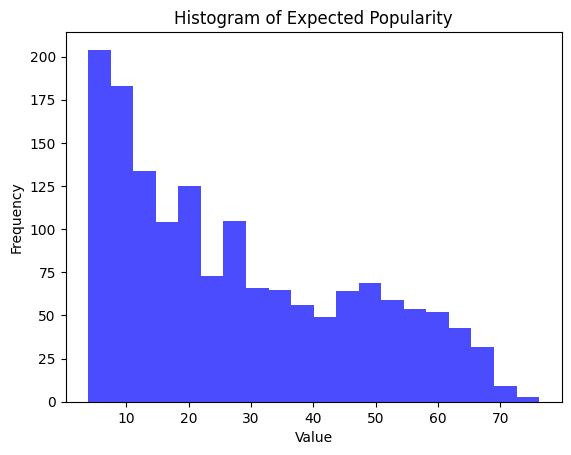

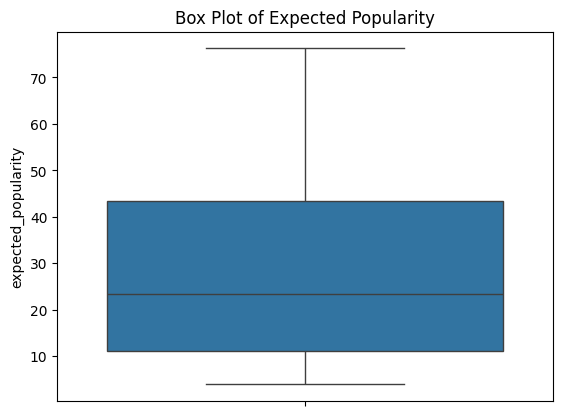

count    1549.000000
mean       27.948555
std        18.766642
min         3.893504
25%        11.129136
50%        23.320973
75%        43.466726
max        76.244155
Name: expected_popularity, dtype: float64

In [3]:
# make predictions and put in original dataframe
raw_dancehall_df['expected_popularity'] = best_model.predict(final_modelling_df)

# view histogram
plt.hist(raw_dancehall_df['expected_popularity'], bins=20, color='blue', alpha=0.7)
plt.title('Histogram of Expected Popularity')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

# view boxplot
sns.boxplot(raw_dancehall_df['expected_popularity'])
plt.title('Box Plot of Expected Popularity')
plt.show()

raw_dancehall_df['expected_popularity'].describe()

#### shap analysis

from the plot below, here are a few insights:

a decent chunk of the dancehall tracks are penalized for having a low follower count *(shown by the long blue tail on the left of the mean prediction line)* however, there are a few tracks with a high enough follower count to get the higher expected popularity score *(shown by the red dots to the right of the mean prediction line.)*

on the other hand, the dancehall tracks don't get penalized too much for having older release years and quite a few even get rewarded for more recent release years *(shown by most of the red points to the right)*. this is more of a feature of the genre though, since trinidad dancehall is a relatively new genre.

another interesting observation is that the dancehall tracks are penalized for having high `speechiness`, `acousticness` and low `liveness`. 

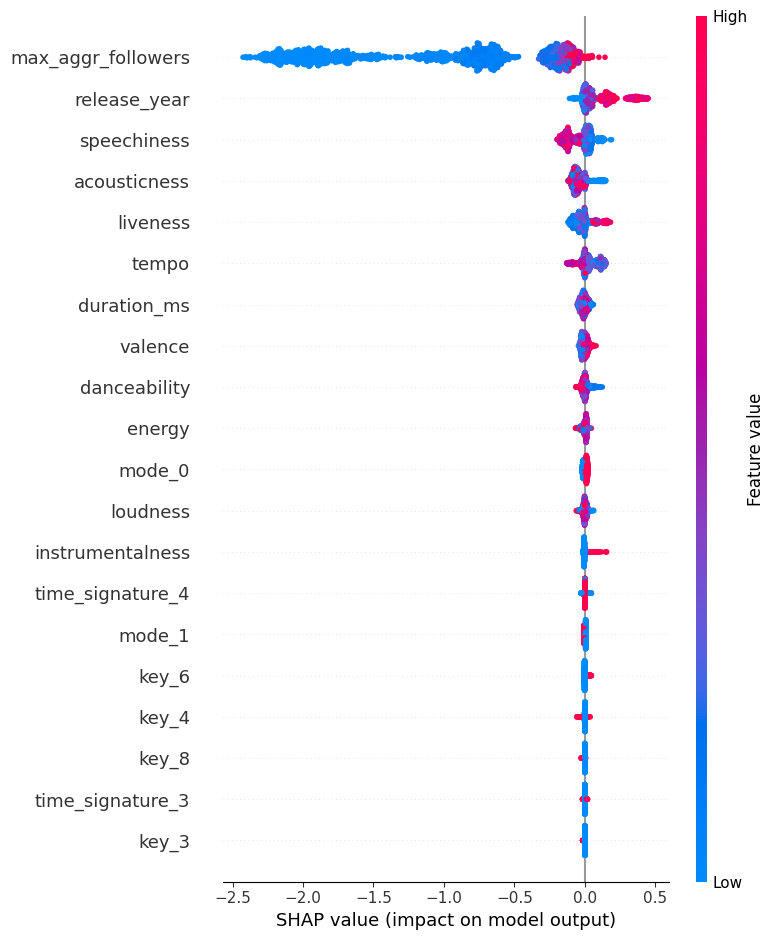

In [14]:
import shap

# compute shap vals
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(final_modelling_df)

# visualize
shap.summary_plot(shap_values, final_modelling_df)

### top-scored tracks

taking a look at the top 20 highest scoring tracks, a few insights arise:

* the majority of these tracks were released in 2023 *(the same year that the data was pulled from)* and so the recency of these tracks likely contribute to their higher score.

* while the second highest track features a collab from a prominent US artist, most of the highly scored tracks have artistes with a moderate follower count (< 200K)

* since the data was pulled as of Dec 2023, the model's scores seem to hold some predictive value as many of the artists in the top 20 tracks have since gone on to gain decent popularity globally e.g. Squash, Byron Messia, Teejay, Skeng, Kraff Gad, Intence, Valiant, Tommy Lee Sparta, Medz Boss, Chronic Law.

In [5]:
# get the top 20 highest scored tracks
top_tracks = raw_dancehall_df.sort_values(by='expected_popularity', ascending=False).head(20)
top_tracks[['track_name', 'track_artists_name', 'track_artists_followers', 'release_date', 'expected_popularity', 'popularity']]

,track_name,track_artists_name,track_artists_followers,release_date,expected_popularity,popularity
track_id,,,,,,
0tE6rjKOG5YfpJtaFq7RW8,Listen Mi Nuh Gyal,"Bounty Killer,Koncept Da Professor","244395,8",2023-01-27,76.244155,6
6K9ULKDxIVIxRH5FXPgLoq,Nightmares (feat. Byron Messia),"Chris Brown,Byron Messia","21023407,61748",2023-11-07,74.635586,61
4pQh1nFlbv7J9cs2g6Ag4X,Be Somebody,Medz Boss,33706,2023-06-19,72.695217,14
0ydoqpTVhaDzjDg7WVcg4m,Drift,Teejay,184254,2023-06-30,71.234695,65
4o1m83MlsAk3I9Nsg2u0TX,‘87 Stingray,Tory Lanez,6254928,2023-11-17,70.934590,50
2RMtOsDs5KGsIT5fW3Dg04,Ms Ontario,Vybz Kartel,1270334,2023-07-26,70.647030,24
3b2M5gLUNCPDtcY8HE6jv6,Shottaz,"Skeng,Kraff Gad","263999,64051",2023-03-31,70.580237,42
22hFjD0W6IHzWybdZ7Yijv,Play Time Done,Squash,161928,2023-03-29,70.549239,30
2QfsZw4OPofO9sCZDP7DQH,Lonely Road,Intence,131215,2023-02-01,69.897670,15
